# GCC128 — Inteligência Artificial
## Trabalho Prático 02 — Agrupamento com K-Means

Aplicação de **aprendizado não supervisionado** com o algoritmo K-Means sobre a base Iris.
O algoritmo foi implementado do zero, assim como as métricas WCSS e Silhouette.

Os rótulos das espécies **não** entram no algoritmo em momento algum — são usados apenas
ao final, para analisar o que os grupos encontrados significam.

## 1. Importações e parâmetros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

VALORES_K = list(range(2, 11))   # K de 2 a 10
SEMENTE = 42                     # reprodutibilidade
N_INIT = 10                      # execucoes por K (o K-Means cai em minimos locais)

ROXO, VERDE, DOURADO = "#5B3E8E", "#7FA88C", "#D99A3E"
CORES = [ROXO, VERDE, DOURADO, "#C0504D", "#4F81BD", "#9BBB59",
         "#8064A2", "#4BACC6", "#F79646"]

## 2. Dados e padronização

A base Iris tem 150 amostras, 4 atributos e 3 espécies.

**Sobre a escolha de padronizar.** A padronização (Z-score) centra cada atributo na média e
divide pelo desvio padrão, evitando que atributos de escala maior dominem a distância
euclidiana. Na Iris, porém, os quatro atributos já estão na mesma unidade (centímetros) e na
mesma ordem de grandeza — a padronização não é obrigatória aqui.

Por isso o experimento roda nos **dois cenários**, brutos e padronizados, para medir o efeito
dessa decisão em vez de assumi-la.

In [2]:
def carregar_dados():
    base = load_iris()
    return base.data, base.target, base.target_names


def padronizar(X):
    """Z-score: cada atributo centrado na media e escalado pelo desvio padrao."""
    return (X - X.mean(axis=0)) / X.std(axis=0)


X, y, nomes = carregar_dados()
Xp = padronizar(X)

print(f"Base Iris: {X.shape[0]} amostras, {X.shape[1]} atributos, {len(nomes)} especies")
print(f"Especies (usadas so na analise final): {list(nomes)}")
print(f"\nAmplitude dos atributos (dados brutos):   {np.round(X.max(0) - X.min(0), 2)}")
print(f"Desvio padrao dos atributos (brutos):      {np.round(X.std(0), 2)}")
print(f"Desvio padrao apos padronizacao:           {np.round(Xp.std(0), 2)}")

Base Iris: 150 amostras, 4 atributos, 3 especies
Especies (usadas so na analise final): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Amplitude dos atributos (dados brutos):   [3.6 2.4 5.9 2.4]
Desvio padrao dos atributos (brutos):      [0.83 0.43 1.76 0.76]
Desvio padrao apos padronizacao:           [1. 1. 1. 1.]


## 3. K-Means implementado do zero

O algoritmo segue o ciclo clássico:

1. **Inicializar** K centróides
2. **Atribuir** cada ponto ao centróide mais próximo
3. **Atualizar** cada centróide para a média dos pontos do seu grupo
4. **Repetir** até os centróides pararem de se mover

Para a inicialização usamos o **k-means++**: o primeiro centróide é sorteado uniformemente e
cada seguinte é sorteado com probabilidade proporcional ao quadrado da distância ao centróide
mais próximo já escolhido. Isso espalha os centróides iniciais e reduz a chance de cair num
mínimo local ruim — problema levantado nos slides da disciplina.

Ainda assim, o K-Means só garante convergência para um **mínimo local**. Por isso cada K é
executado 10 vezes e fica a solução de menor WCSS.

In [3]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def inicializar_centroides(X, k, rng):
    """k-means++: espalha os centroides iniciais."""
    centroides = [X[rng.integers(len(X))]]
    for _ in range(k - 1):
        d2 = np.array([min(distancia_euclidiana(x, c) ** 2 for c in centroides) for x in X])
        centroides.append(X[rng.choice(len(X), p=d2 / d2.sum())])
    return np.array(centroides)


def atribuir_clusters(X, centroides):
    """Cada ponto vai para o centroide mais proximo."""
    rotulos = np.empty(len(X), dtype=int)
    for i, amostra in enumerate(X):
        rotulos[i] = int(np.argmin([distancia_euclidiana(amostra, c) for c in centroides]))
    return rotulos


def atualizar_centroides(X, rotulos, k, centroides_antigos):
    """Novo centroide = media aritmetica dos pontos do cluster."""
    novos = np.empty((k, X.shape[1]))
    for j in range(k):
        pontos = X[rotulos == j]
        novos[j] = pontos.mean(axis=0) if len(pontos) > 0 else centroides_antigos[j]
    return novos

## 4. WCSS e critério de parada

O **WCSS** (*Within-Cluster Sum of Squares*), também chamado de inércia ou SSE, é a soma dos
quadrados das distâncias de cada ponto ao centróide do seu grupo. É a função que o K-Means
minimiza a cada iteração.

In [4]:
def calcular_wcss(X, rotulos, centroides):
    """Soma dos quadrados das distancias intra-cluster (inercia / SSE)."""
    return float(sum(distancia_euclidiana(x, centroides[rotulos[i]]) ** 2
                     for i, x in enumerate(X)))


def kmeans_uma_execucao(X, k, rng, max_iter=300, tol=1e-6):
    centroides = inicializar_centroides(X, k, rng)
    for iteracao in range(1, max_iter + 1):
        rotulos = atribuir_clusters(X, centroides)
        novos = atualizar_centroides(X, rotulos, k, centroides)
        deslocamento = max(distancia_euclidiana(a, b) for a, b in zip(centroides, novos))
        centroides = novos
        if deslocamento <= tol:
            break
    rotulos = atribuir_clusters(X, centroides)
    return rotulos, centroides, calcular_wcss(X, rotulos, centroides), iteracao


def kmeans(X, k, semente=SEMENTE, n_init=N_INIT):
    """Executa n_init vezes e devolve a solucao de menor WCSS."""
    rng = np.random.default_rng(semente)
    melhor = None
    for _ in range(n_init):
        r = kmeans_uma_execucao(X, k, rng)
        if melhor is None or r[2] < melhor[2]:
            melhor = r
    return melhor

## 5. Silhouette Score implementado do zero

Para cada amostra *i*:

- **a(i)** = distância média de *i* às demais amostras do **seu próprio** grupo (coesão)
- **b(i)** = menor distância média de *i* às amostras de **outro** grupo (separação)
- **s(i) = (b − a) / max(a, b)**

O valor varia de −1 a 1. Perto de 1 a amostra está bem alocada; perto de 0 está na fronteira
entre dois grupos; negativo sugere que ela estaria melhor em outro grupo. O Silhouette Score
do agrupamento é a média de s(i).

In [5]:
def silhouette_por_amostra(X, rotulos):
    n = len(X)
    D = np.array([[distancia_euclidiana(X[i], X[j]) for j in range(n)] for i in range(n)])
    valores = np.zeros(n)
    for i in range(n):
        proprio = rotulos == rotulos[i]
        proprio[i] = False
        if proprio.sum() == 0:
            continue
        a = D[i][proprio].mean()                                    # coesao
        b = min(D[i][rotulos == c].mean()                           # separacao
                for c in np.unique(rotulos) if c != rotulos[i])
        valores[i] = (b - a) / max(a, b)
    return valores


def silhouette(X, rotulos):
    return float(np.mean(silhouette_por_amostra(X, rotulos)))

## 6. Execução para diferentes valores de K

O algoritmo roda para K de 2 a 10, nos dois cenários de pré-processamento.

In [6]:
cenarios = {"brutos": X, "padronizados": Xp}
resultados = {}

for nome, dados in cenarios.items():
    linhas = []
    for k in VALORES_K:
        rot, cen, wcss, it = kmeans(dados, k)
        linhas.append((k, wcss, silhouette(dados, rot), it))
    resultados[nome] = linhas

    print(f"\n=== DADOS {nome.upper()} ===")
    print(f"{'K':>3}{'WCSS':>12}{'Silhouette':>13}{'iteracoes':>11}")
    for k, w, s, it in linhas:
        print(f"{k:>3}{w:>12.3f}{s:>13.4f}{it:>11}")


=== DADOS BRUTOS ===
  K        WCSS   Silhouette  iteracoes
  2     152.348       0.6810          4
  3      78.851       0.5528          6
  4      57.256       0.4975          9
  5      46.446       0.4887          4
  6      39.040       0.3648         17
  7      34.386       0.3532         14
  8      30.187       0.3575          8
  9      28.073       0.3151         10
 10      26.192       0.3237          6



=== DADOS PADRONIZADOS ===
  K        WCSS   Silhouette  iteracoes
  2     222.362       0.5818          3
  3     139.820       0.4599          6
  4     114.505       0.4133          6
  5      90.808       0.3455          9
  6      80.860       0.3354         14
  7      71.620       0.3286         10
  8      63.103       0.3217          7
  9      54.121       0.3489          8
 10      47.498       0.3596         11


## 7. Método do Cotovelo

O WCSS sempre cai quando K aumenta — no limite, com K igual ao número de amostras, ele chega a
zero. Por isso o critério não é o menor WCSS, e sim o ponto em que a curva **deixa de cair
acentuadamente**: o cotovelo. A partir dali, aumentar K traz pouco ganho e apenas fragmenta
grupos que já eram coerentes.

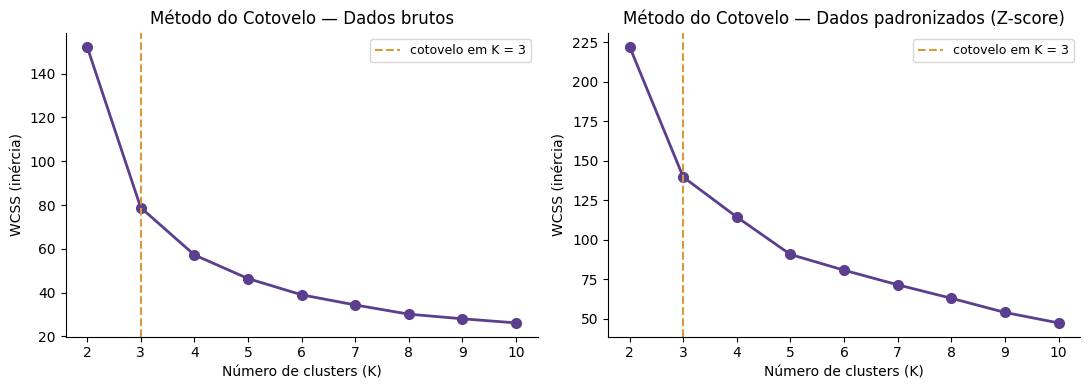

  K       WCSS   queda vs K-1   queda %   (dados brutos)
  2    152.348              —         —
  3     78.851         73.497     48.2%
  4     57.256         21.595     27.4%
  5     46.446         10.810     18.9%
  6     39.040          7.406     15.9%
  7     34.386          4.654     11.9%
  8     30.187          4.199     12.2%
  9     28.073          2.114      7.0%
 10     26.192          1.881      6.7%


In [7]:
def plotar_cotovelo(valores_k, wcss_brutos, wcss_padr):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    for ax, wcss, titulo in [(ax1, wcss_brutos, "Dados brutos"),
                             (ax2, wcss_padr, "Dados padronizados (Z-score)")]:
        ax.plot(valores_k, wcss, "o-", color=ROXO, linewidth=2, markersize=7)
        ax.axvline(3, color=DOURADO, linestyle="--", linewidth=1.5, label="cotovelo em K = 3")
        ax.set_xlabel("Número de clusters (K)")
        ax.set_ylabel("WCSS (inércia)")
        ax.set_title(f"Método do Cotovelo — {titulo}")
        ax.set_xticks(valores_k)
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


plotar_cotovelo(VALORES_K, [r[1] for r in resultados["brutos"]],
                [r[1] for r in resultados["padronizados"]])

print(f"{'K':>3}{'WCSS':>11}{'queda vs K-1':>15}{'queda %':>10}   (dados brutos)")
anterior = None
for k, w, _, _ in resultados["brutos"]:
    if anterior is None:
        print(f"{k:>3}{w:>11.3f}{'—':>15}{'—':>10}")
    else:
        print(f"{k:>3}{w:>11.3f}{anterior - w:>15.3f}{(anterior - w) / anterior * 100:>9.1f}%")
    anterior = w

## 8. Silhouette Score por valor de K

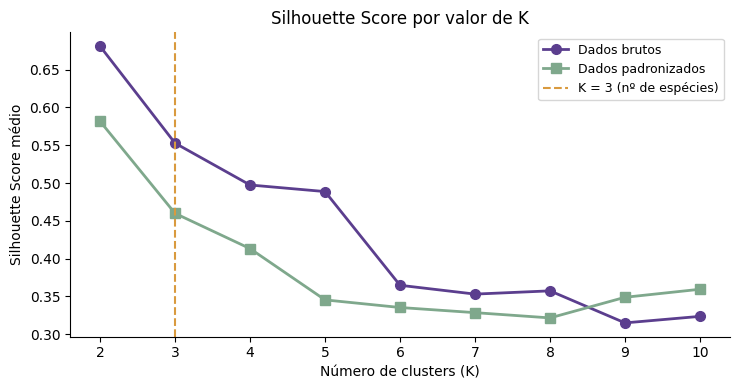

Dados brutos: melhor Silhouette em K = 2 (0.6810)
Dados padronizados: melhor Silhouette em K = 2 (0.5818)


In [8]:
def plotar_silhouette_por_k(valores_k, sil_brutos, sil_padr):
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(valores_k, sil_brutos, "o-", color=ROXO, linewidth=2,
            markersize=7, label="Dados brutos")
    ax.plot(valores_k, sil_padr, "s-", color=VERDE, linewidth=2,
            markersize=7, label="Dados padronizados")
    ax.axvline(3, color=DOURADO, linestyle="--", linewidth=1.5,
               label="K = 3 (nº de espécies)")
    ax.set_xlabel("Número de clusters (K)")
    ax.set_ylabel("Silhouette Score médio")
    ax.set_title("Silhouette Score por valor de K")
    ax.set_xticks(valores_k)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


plotar_silhouette_por_k(VALORES_K, [r[2] for r in resultados["brutos"]],
                        [r[2] for r in resultados["padronizados"]])

for nome in cenarios:
    melhor = max(resultados[nome], key=lambda r: r[2])
    print(f"Dados {nome}: melhor Silhouette em K = {melhor[0]} ({melhor[2]:.4f})")

### Interpretação: cotovelo e silhueta discordam

O cotovelo aponta **K = 3** nos dois cenários. A silhueta, porém, é máxima em **K = 2**.

A discordância não é um erro — as duas métricas medem coisas diferentes. O cotovelo procura o
ponto de retorno decrescente na compactação dos grupos; a silhueta premia grupos bem
**separados** entre si. Na Iris, uma das espécies fica isolada das outras duas, que se
sobrepõem. Separar essas duas cria uma fronteira artificial no meio de uma região densa, o
que derruba a silhueta, mesmo sendo a partição correta do ponto de vista biológico.

Isso ilustra um ponto central do aprendizado não supervisionado: as métricas descrevem a
**geometria** dos dados, não a estrutura semântica que buscamos. Adotamos **K = 3**, apoiados
no cotovelo e no conhecimento do domínio.

## 9. Visualização dos agrupamentos com PCA

A base tem 4 atributos, o que impede a visualização direta. Usamos **PCA** para projetar os
dados em 2 componentes principais. A PCA é adequada aqui porque as duas primeiras componentes
concentram quase toda a variância, preservando a estrutura de distâncias que o K-Means usa.

O primeiro painel mostra as espécies reais, apenas como referência visual — elas não
participaram do agrupamento.

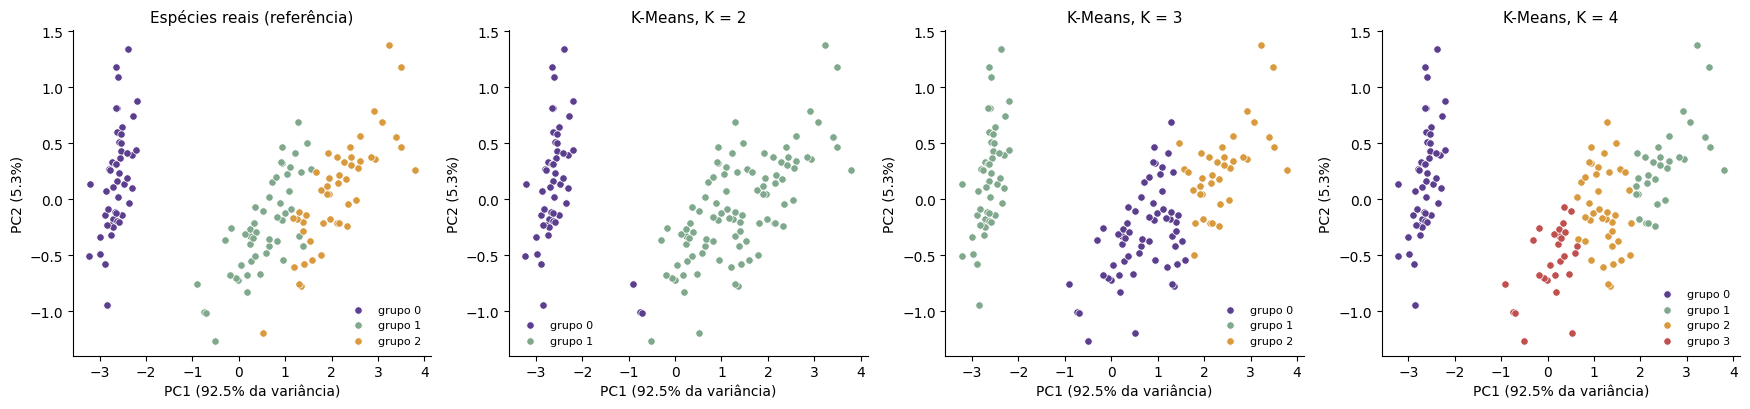

Variancia explicada pelas 2 primeiras componentes: 97.8%


In [9]:
def plotar_clusters_pca(X, particoes, titulos):
    pca = PCA(n_components=2, random_state=SEMENTE)
    Z = pca.fit_transform(X)
    var = pca.explained_variance_ratio_
    fig, axes = plt.subplots(1, len(particoes), figsize=(4.4 * len(particoes), 4.2),
                             squeeze=False)
    for ax, rotulos, titulo in zip(axes[0], particoes, titulos):
        for j, c in enumerate(np.unique(rotulos)):
            p = Z[rotulos == c]
            ax.scatter(p[:, 0], p[:, 1], s=28, color=CORES[j % len(CORES)],
                       edgecolor="white", linewidth=0.5, label=f"grupo {c}")
        ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% da variância)")
        ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
        ax.set_title(titulo, fontsize=11)
        ax.legend(fontsize=8, frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()
    print(f"Variancia explicada pelas 2 primeiras componentes: {var.sum()*100:.1f}%")


r2, r3, r4 = kmeans(X, 2), kmeans(X, 3), kmeans(X, 4)
plotar_clusters_pca(X, [y, r2[0], r3[0], r4[0]],
                    ["Espécies reais (referência)", "K-Means, K = 2",
                     "K-Means, K = 3", "K-Means, K = 4"])

A comparação visual mostra o efeito de K com clareza. Com **K = 2**, o grupo isolado à
esquerda é separado corretamente, mas as duas espécies da direita são fundidas. Com **K = 3**,
a partição se aproxima bastante das espécies reais, errando apenas na fronteira entre os dois
grupos sobrepostos. Com **K = 4**, um grupo coeso é partido ao meio sem que exista qualquer
separação real nos dados — o algoritmo obedece ao K imposto, mesmo sem estrutura que o
justifique.

## 10. Qualidade do agrupamento escolhido (K = 3)

O gráfico de silhueta por amostra mostra a distribuição interna de cada grupo, e não apenas a
média.

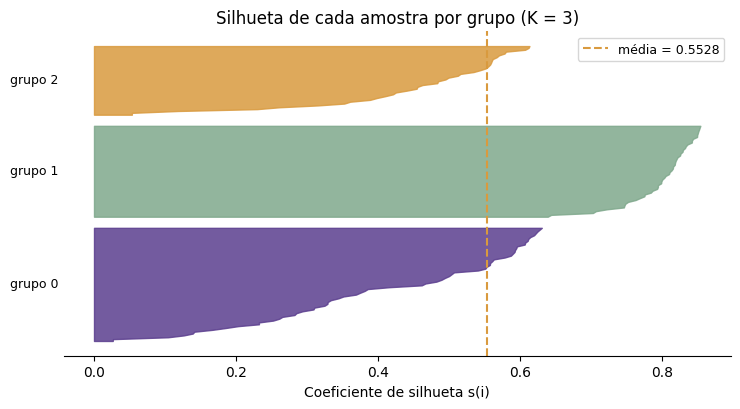

grupo 0:  62 amostras | silhueta media 0.4173 | minima 0.0264 | negativas: 0
grupo 1:  50 amostras | silhueta media 0.7981 | minima 0.6390 | negativas: 0
grupo 2:  38 amostras | silhueta media 0.4511 | minima 0.0533 | negativas: 0


In [10]:
def plotar_silhouette_amostras(X, rotulos):
    valores = silhouette_por_amostra(X, rotulos)
    media = valores.mean()
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    base = 5
    for j, c in enumerate(np.unique(rotulos)):
        v = np.sort(valores[rotulos == c])
        ax.fill_betweenx(np.arange(base, base + len(v)), 0, v,
                         color=CORES[j % len(CORES)], alpha=0.85)
        ax.text(-0.05, base + len(v) / 2, f"grupo {c}", ha="right", va="center", fontsize=9)
        base += len(v) + 5
    ax.axvline(media, color=DOURADO, linestyle="--", linewidth=1.5,
               label=f"média = {media:.4f}")
    ax.set_xlabel("Coeficiente de silhueta s(i)")
    ax.set_yticks([])
    ax.set_title("Silhueta de cada amostra por grupo (K = 3)")
    ax.legend(fontsize=9)
    ax.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    plt.show()

    for c in np.unique(rotulos):
        v = valores[rotulos == c]
        print(f"grupo {c}: {len(v):>3} amostras | silhueta media {v.mean():.4f} | "
              f"minima {v.min():.4f} | negativas: {(v < 0).sum()}")


plotar_silhouette_amostras(X, r3[0])

## 11. Análise dos grupos encontrados

Só agora os rótulos das espécies entram, para **interpretar** o que os grupos representam.
A matriz de contingência cruza espécie real com grupo atribuído. Note que os números dos
grupos são arbitrários: o K-Means não nomeia nada, apenas particiona.

O **ARI** (*Adjusted Rand Index*) resume a concordância entre as duas partições, corrigida
pelo acaso: 1,0 é concordância total e 0 é o esperado de uma atribuição aleatória.

In [11]:
from sklearn.metrics import adjusted_rand_score

def matriz_contingencia(reais, clusters, n_classes, k):
    m = np.zeros((n_classes, k), dtype=int)
    for real, c in zip(reais, clusters):
        m[real][c] += 1
    return m


for nome, dados in cenarios.items():
    rot, cen, wcss, _ = kmeans(dados, 3)
    m = matriz_contingencia(y, rot, 3, 3)
    print(f"\n=== DADOS {nome.upper()}, K = 3 ===")
    print(f"{'especie \\ grupo':>18}" + "".join(f"{f'grupo {j}':>10}" for j in range(3)))
    for i, nome_esp in enumerate(nomes):
        print(f"{nome_esp:>18}" + "".join(f"{v:>10}" for v in m[i]))
    print(f"WCSS = {wcss:.3f} | Silhouette = {silhouette(dados, rot):.4f} | "
          f"ARI = {adjusted_rand_score(y, rot):.4f}")


=== DADOS BRUTOS, K = 3 ===
   especie \ grupo   grupo 0   grupo 1   grupo 2
            setosa         0        50         0
        versicolor        48         0         2
         virginica        14         0        36


WCSS = 78.851 | Silhouette = 0.5528 | ARI = 0.7302



=== DADOS PADRONIZADOS, K = 3 ===
   especie \ grupo   grupo 0   grupo 1   grupo 2
            setosa        50         0         0
        versicolor         0        11        39
         virginica         0        36        14


WCSS = 139.820 | Silhouette = 0.4599 | ARI = 0.6201


### Efeito da normalização

Os dois cenários levam ao mesmo K pelo cotovelo, mas produzem partições de qualidade
diferente. Nos **dados brutos** o agrupamento fica mais alinhado às espécies (ARI mais alto) e
com silhueta melhor; a padronização **piora** os dois indicadores.

A explicação está na natureza dos atributos. Padronizar dá peso igual a todos eles, e na Iris
isso prejudica: comprimento e largura da pétala são os atributos que realmente distinguem as
espécies, enquanto a largura da sépala discrimina pouco. Ao equalizar as escalas, a
padronização amplifica a influência do atributo menos informativo e dilui a dos mais úteis.

A conclusão prática é que padronizar **não é um passo automático**. É indicado quando os
atributos estão em unidades ou ordens de grandeza distintas — o caso de altura, peso e salário,
por exemplo. Quando já estão na mesma unidade e a diferença de dispersão carrega informação
real, como aqui, padronizar pode destruir justamente o sinal que interessa. Por isso o
trabalho reporta os dois cenários em vez de assumir a padronização.

## 12. Validação da implementação

Conferência rápida contra o Scikit-learn, apenas para confirmar que a implementação do zero
está correta. A biblioteca não foi usada no agrupamento em si.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rot, cen, wcss, _ = kmeans(X, 3)
sk = KMeans(n_clusters=3, n_init=10, random_state=SEMENTE).fit(X)

print(f"WCSS       — propria: {wcss:.4f} | sklearn (inertia_): {sk.inertia_:.4f}")
print(f"Silhouette — propria: {silhouette(X, rot):.4f} | "
      f"sklearn: {silhouette_score(X, sk.labels_):.4f}")
print(f"ARI entre as duas particoes: {adjusted_rand_score(rot, sk.labels_):.4f}")

WCSS       — propria: 78.8514 | sklearn (inertia_): 78.8514


Silhouette — propria: 0.5528 | sklearn: 0.5528
ARI entre as duas particoes: 1.0000


## 13. Limitações do K-Means

Os experimentos expõem várias limitações do algoritmo:

- **K é um parâmetro de entrada.** O algoritmo não descobre quantos grupos existem. Com K = 4
  ele partiu um grupo coeso ao meio sem hesitar, porque obedecer ao K é o objetivo.
- **Convergência apenas para mínimo local.** O resultado depende da inicialização. Mitigamos
  com k-means++ e 10 execuções por K, ficando com a de menor WCSS, mas não há garantia de
  ótimo global.
- **Grupos globulares e de tamanho similar.** Como cada ponto vai ao centróide mais próximo
  por distância euclidiana, as fronteiras são lineares. Grupos alongados, aninhados ou em
  formato de anel não são recuperados.
- **Sensibilidade à escala dos atributos.** Vista na seção anterior: a mesma base leva a
  partições diferentes conforme a decisão de padronizar.
- **Sensibilidade a outliers.** O centróide é uma média, e médias são puxadas por valores
  extremos. Um ponto distante desloca o centro de todo o grupo.
- **Todo ponto é obrigatoriamente atribuído.** Não existe a categoria "ruído"; outliers são
  forçados para dentro de algum grupo. Métodos por densidade, como o DBSCAN, tratam isso.

## 14. Conclusão

O K-Means foi implementado do zero, incluindo a inicialização k-means++, o ciclo de atribuição
e atualização, o critério de convergência e as métricas WCSS e Silhouette. A validação contra
o Scikit-learn produziu valores idênticos, confirmando a corretude.

Sobre a escolha de K, o Método do Cotovelo apontou K = 3 de forma consistente nos dois
cenários, coincidindo com o número real de espécies. A silhueta apontou K = 2 — discordância
que se explica pela sobreposição de duas das espécies, e que ilustra por que, em problemas não
supervisionados, nenhuma métrica isolada deve decidir sozinha.

Com K = 3 sobre os dados brutos, o agrupamento recuperou uma das espécies integralmente e
separou as outras duas com erro restrito à região de sobreposição. A padronização, testada
como cenário alternativo, piorou os resultados nesta base específica — um lembrete de que
pré-processamento é uma decisão a ser justificada pelos dados, não um passo automático.